### Configuration, inputs & outputs

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from scipy.stats import mannwhitneyu

from pipeline_utils import make_case3_paths

paths = make_case3_paths()

## Raw omics matrices (for gene-coverage check)
mcgill_mut_raw = paths["datasets"] / "mcgill_breast" / "mutation_matrix.csv"
mcgill_cnv_raw = paths["datasets"] / "mcgill_breast" / "CNV_matrix.csv"
uhn_mut_raw = paths["datasets"] / "uhn_breast" / "mutation_matrix.csv"
uhn_cnv_raw = paths["datasets"] / "uhn_breast" / "CNV_matrix.csv"
gene_file = paths["raw"] / "nest_vnn" / "gene2ind.txt"

## Final NeST-VNN input matrices (cell x gene, binary; row order matches cell2ind.txt)
mcgill_dir = paths["proc"] / "McGill_nest_input"
uhn_complete_dir = paths["proc"] / "UHN_nest_input" / "complete_cohort"
uhn_strict_dir = paths["proc"] / "UHN_nest_input" / "strict_cohort"

## Output
figures_dir = paths["results"]
figures_dir.mkdir(parents=True, exist_ok=True)

### Gene coverage: how many of the 718 NeST-VNN genes have data in each cohort

In [2]:
gene_list = pd.read_csv(gene_file, sep="\t", header=None)[1].tolist()
print("NeST-VNN target genes:", len(gene_list))


def n_covered(matrix_path, gene_list):
    genes_present = set(pd.read_csv(matrix_path, index_col=0).index)
    return sum(g in genes_present for g in gene_list)


coverage = pd.DataFrame([
    {"cohort": "UHN Carboplatin", "data_type": "Mutation", "genes_covered": n_covered(uhn_mut_raw, gene_list)},
    {"cohort": "UHN Carboplatin", "data_type": "CNV", "genes_covered": n_covered(uhn_cnv_raw, gene_list)},
    {"cohort": "McGill Cisplatin", "data_type": "Mutation", "genes_covered": n_covered(mcgill_mut_raw, gene_list)},
    {"cohort": "McGill Cisplatin", "data_type": "CNV", "genes_covered": n_covered(mcgill_cnv_raw, gene_list)},
])
coverage["total_genes"] = len(gene_list)
coverage["pct_covered"] = (coverage["genes_covered"] / len(gene_list) * 100).round(1)
print(coverage.to_string(index=False))

NeST-VNN target genes: 718
          cohort data_type  genes_covered  total_genes  pct_covered
 UHN Carboplatin  Mutation            670          718         93.3
 UHN Carboplatin       CNV            711          718         99.0
McGill Cisplatin  Mutation            235          718         32.7
McGill Cisplatin       CNV            717          718         99.9


### Gene coverage plot

Saved: /Users/guanqiaofeng/Documents/BHK/XevaDB/Manuscript_gitrepo/XevaDB_case_study/results/3_carboplatin/case3_gene_coverage.png


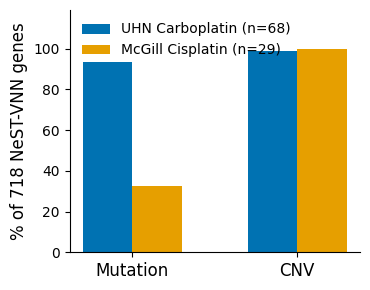

In [3]:
COHORT_COLORS = {"UHN Carboplatin": "#0072B2", "McGill Cisplatin": "#E69F00"}
COHORT_N = {"UHN Carboplatin": 68, "McGill Cisplatin": 29}

fig, ax = plt.subplots(figsize=(3.8, 3))

data_types = ["Mutation", "CNV"]
x = np.arange(len(data_types)) * 0.6
width = 0.18

for offset, cohort in zip([-width / 2, width / 2], COHORT_COLORS):
    sub = coverage[coverage["cohort"] == cohort].set_index("data_type").loc[data_types]
    bars = ax.bar(x + offset, sub["pct_covered"], width, label=f"{cohort} (n={COHORT_N[cohort]})", color=COHORT_COLORS[cohort])
    # for bar, pct, n in zip(bars, sub["pct_covered"], sub["genes_covered"]):
    #     ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1.5, f"{n}/718",
    #              ha="center", va="bottom", fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(data_types, fontsize=12)
ax.set_ylabel("% of 718 NeST-VNN genes", fontsize=12)
ax.set_ylim(0, 119)
# ax.set_title("Gene coverage completeness by cohort")
ax.legend(frameon=False, loc="upper left")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()

out_path = figures_dir / "case3_gene_coverage.png"
plt.savefig(out_path, dpi=300)
print("Saved:", out_path)
plt.show()

### Does the Mutation gene-coverage gap (panel b) confound the Mutation significance test (panel c)?

Panel b shows McGill has real mutation data for only 235/718 NeST-VNN genes vs. UHN's 670/718. Since
uncovered genes are filled with 0 ("no mutation") in the final matrices, McGill's per-model mutation
counts could be artificially low simply because ~483 genes were never observed, not because McGill
models are truly less mutated. To check: restrict the comparison to only the genes **both cohorts
actually have coverage for**, and re-run the same Mann-Whitney test.

In [4]:
mcgill_mut_genes = set(pd.read_csv(mcgill_mut_raw, index_col=0).index)
uhn_mut_genes = set(pd.read_csv(uhn_mut_raw, index_col=0).index)
common_mut_genes = [g for g in gene_list if g in mcgill_mut_genes and g in uhn_mut_genes]
print(f"Genes with mutation data in BOTH cohorts: {len(common_mut_genes)} / {len(gene_list)}")


def load_mutation_df(nest_dir):
    df = pd.read_csv(nest_dir / "cell2mutation.txt", header=None)
    df.columns = gene_list
    return df


mcgill_mut_df = load_mutation_df(mcgill_dir)
uhn_mut_df = load_mutation_df(uhn_complete_dir)

# Original comparison: all 718 genes (uncovered genes filled with 0)
mcgill_all = mcgill_mut_df.sum(axis=1).to_numpy()
uhn_all = uhn_mut_df.sum(axis=1).to_numpy()
stat_all, p_all = mannwhitneyu(uhn_all, mcgill_all, alternative="two-sided")
print(f"\nMutation, all 718 genes:        U={stat_all:.1f}, p={p_all:.2e} "
      f"(McGill median={np.median(mcgill_all):.1f}, UHN median={np.median(uhn_all):.1f})")

# Restricted comparison: only genes both cohorts actually have coverage for
mcgill_common = mcgill_mut_df[common_mut_genes].sum(axis=1).to_numpy()
uhn_common = uhn_mut_df[common_mut_genes].sum(axis=1).to_numpy()
stat_c, p_c = mannwhitneyu(uhn_common, mcgill_common, alternative="two-sided")
print(f"Mutation, {len(common_mut_genes)} common-covered genes: U={stat_c:.1f}, p={p_c:.2e} "
      f"(McGill median={np.median(mcgill_common):.1f}, UHN median={np.median(uhn_common):.1f})")

print("\n-> The difference weakens substantially once uncovered genes are excluded, but remains "
      "statistically significant -- the coverage gap inflates the effect, but doesn't fully explain it.")

Genes with mutation data in BOTH cohorts: 232 / 718

Mutation, all 718 genes:        U=1824.5, p=3.81e-11 (McGill median=7.0, UHN median=17.5)
Mutation, 232 common-covered genes: U=1348.0, p=4.23e-03 (McGill median=7.0, UHN median=9.0)

-> The difference weakens substantially once uncovered genes are excluded, but remains statistically significant -- the coverage gap inflates the effect, but doesn't fully explain it.


#### Supplemental panel: Mutation burden, all 718 genes vs. common-covered genes only

  All 718
genes: U=1824.5, p=3.81e-11 (****)
  Common 232
genes: U=1348.0, p=4.23e-03 (**)
Saved: /Users/guanqiaofeng/Documents/BHK/XevaDB/Manuscript_gitrepo/XevaDB_case_study/results/3_carboplatin/case3_mutation_coverage_confound_check.png


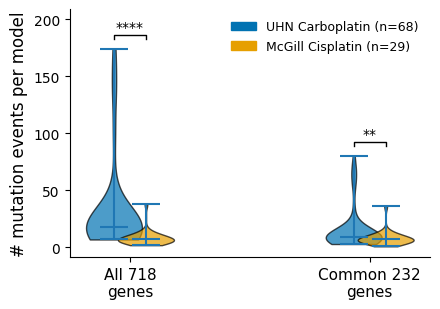

In [5]:
GROUPS = [
    ("All 718\ngenes", mcgill_all, uhn_all),
    (f"Common {len(common_mut_genes)}\ngenes", mcgill_common, uhn_common),
]

fig, ax = plt.subplots(figsize=(4.5, 3.2))

positions, plot_data, colors = [], [], []
xticks, xticklabels = [], []
for i, (label, mcgill_vals, uhn_vals) in enumerate(GROUPS):
    plot_data += [uhn_vals, mcgill_vals]
    positions += [i * 3 + 0.8, i * 3 + 1.2]
    colors += [COHORT_COLORS["UHN Carboplatin"], COHORT_COLORS["McGill Cisplatin"]]
    xticks.append(i * 3 + 1)
    xticklabels.append(label)

parts = ax.violinplot(plot_data, positions=positions, widths=0.7, showmedians=True)
for pc, color in zip(parts["bodies"], colors):
    pc.set_facecolor(color)
    pc.set_alpha(0.7)
    pc.set_edgecolor("black")

ax.set_xticks(xticks)
ax.set_xticklabels(xticklabels, fontsize=11)
ax.set_ylabel("# mutation events per model", fontsize=12)
ax.legend(
    handles=[
        Patch(color=COHORT_COLORS["UHN Carboplatin"], label=f"UHN Carboplatin (n={len(uhn_all)})"),
        Patch(color=COHORT_COLORS["McGill Cisplatin"], label=f"McGill Cisplatin (n={len(mcgill_all)})"),
    ],
    frameon=False, loc="upper right", fontsize=9,
)

y_max = max(d.max() for d in plot_data)
cap = y_max * 0.02
gap = y_max * 0.05
for i, (label, mcgill_vals, uhn_vals) in enumerate(GROUPS):
    stat, p = mannwhitneyu(uhn_vals, mcgill_vals, alternative="two-sided")
    if p < 0.0001:
        sig = "****"
    elif p < 0.001:
        sig = "***"
    elif p < 0.01:
        sig = "**"
    elif p < 0.05:
        sig = "*"
    else:
        sig = "ns"
    print(f"  {label.strip()}: U={stat:.1f}, p={p:.2e} ({sig})")

    x1, x2 = i * 3 + 0.8, i * 3 + 1.2
    group_max = max(uhn_vals.max(), mcgill_vals.max())
    y = group_max + gap
    ax.plot([x1, x1, x2, x2], [y, y + cap, y + cap, y], color="black", linewidth=1)
    ax.text((x1 + x2) / 2, y + cap * 1.2, sig, ha="center", va="bottom", fontsize=10)

ax.set_ylim(top=y_max * 1.2)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()

out_path = figures_dir / "case3_mutation_coverage_confound_check.png"
plt.savefig(out_path, dpi=300)
print("Saved:", out_path)
plt.show()

### Per-model event burden: Mutation / CNA / CND

In [6]:
def load_event_counts(nest_dir):
    """Per-model event counts from the final NeST-VNN cell x gene binary matrices."""
    mut = pd.read_csv(nest_dir / "cell2mutation.txt", header=None)
    cna = pd.read_csv(nest_dir / "cell2amplification.txt", header=None)
    cnd = pd.read_csv(nest_dir / "cell2cndeletion.txt", header=None)
    return {
        "Mutation": mut.sum(axis=1).to_numpy(),
        "CNA": cna.sum(axis=1).to_numpy(),
        "CND": cnd.sum(axis=1).to_numpy(),
    }


# UHN "complete" cohort used here (largest available N); "strict" cohort is
# available at uhn_strict_dir if the n_replicates->=2 subset is preferred instead.
mcgill_events = load_event_counts(mcgill_dir)
uhn_events = load_event_counts(uhn_complete_dir)

print(f"McGill Cisplatin: n={len(mcgill_events['Mutation'])}")
print(f"UHN Carboplatin (complete): n={len(uhn_events['Mutation'])}")

McGill Cisplatin: n=29
UHN Carboplatin (complete): n=68


### Density comparison + Mann-Whitney U test

Mann-Whitney U test (two-sided): UHN Carboplatin vs McGill Cisplatin
  Mutation: U=1824.5, p=3.81e-11 (****)
  CNA: U=858.5, p=3.17e-01 (ns)
  CND: U=1175.5, p=1.36e-01 (ns)

Saved: /Users/guanqiaofeng/Documents/BHK/XevaDB/Manuscript_gitrepo/XevaDB_case_study/results/3_carboplatin/case3_feature_density_comparison.png


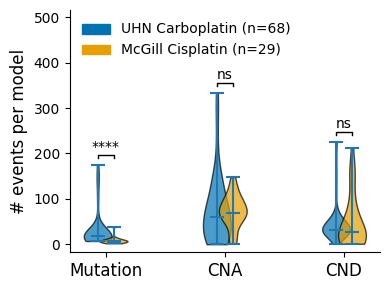

In [7]:
FEATURE_TYPES = ["Mutation", "CNA", "CND"]

fig, ax = plt.subplots(figsize=(4, 3))

positions, plot_data, colors = [], [], []
xticks, xticklabels = [], []
for i, ft in enumerate(FEATURE_TYPES):
    plot_data += [uhn_events[ft], mcgill_events[ft]]
    positions += [i * 3 + 0.8, i * 3 + 1.2]
    colors += [COHORT_COLORS["UHN Carboplatin"], COHORT_COLORS["McGill Cisplatin"]]
    xticks.append(i * 3 + 1)
    xticklabels.append(ft)

parts = ax.violinplot(plot_data, positions=positions, widths=0.7, showmedians=True)
for pc, color in zip(parts["bodies"], colors):
    pc.set_facecolor(color)
    pc.set_alpha(0.7)
    pc.set_edgecolor("black")

ax.set_xticks(xticks)
ax.set_xticklabels(xticklabels, fontsize = 12)
ax.set_ylabel("# events per model", fontsize= 12)
#ax.set_title("Density comparison of 718 NeST-VNN features")
ax.legend(
    handles=[
        Patch(color=COHORT_COLORS["UHN Carboplatin"], label=f"UHN Carboplatin (n={len(uhn_events['Mutation'])})"),
        Patch(color=COHORT_COLORS["McGill Cisplatin"], label=f"McGill Cisplatin (n={len(mcgill_events['Mutation'])})"),
    ],
    frameon=False, loc="upper left", fontsize = 10
)

print("Mann-Whitney U test (two-sided): UHN Carboplatin vs McGill Cisplatin")
y_max = max(d.max() for d in plot_data)
cap = y_max * 0.02
gap = y_max * 0.05
for i, ft in enumerate(FEATURE_TYPES):
    stat, p = mannwhitneyu(uhn_events[ft], mcgill_events[ft], alternative="two-sided")
    if p < 0.0001:
        sig = "****"
    elif p < 0.001:
        sig = "***"
    elif p < 0.01:
        sig = "**"
    elif p < 0.05:
        sig = "*"
    else:
        sig = "ns"
    print(f"  {ft}: U={stat:.1f}, p={p:.2e} ({sig})")

    x1, x2 = i * 3 + 0.8, i * 3 + 1.2
    group_max = max(uhn_events[ft].max(), mcgill_events[ft].max())
    y = group_max + gap
    ax.plot([x1, x1, x2, x2], [y, y + cap, y + cap, y], color="black", linewidth=1)
    ax.text((x1 + x2) / 2, y + cap * 1.2, sig, ha="center", va="bottom", fontsize=10)

ax.set_ylim(top=y_max * 1.55)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()

out_path = figures_dir / "case3_feature_density_comparison.png"
plt.savefig(out_path, dpi=300)
print("\nSaved:", out_path)
plt.show()

### Replicate condition: McGill (single-arm only) vs UHN complete vs UHN strict (>=2 arms)

In [8]:
mcgill_models = pd.read_csv(paths["proc"] / "McGill_cisplatin_models.tsv", sep="\t")
uhn_models = pd.read_csv(paths["proc"] / "UHN_carboplatin_models.tsv", sep="\t")

mcgill_reps = mcgill_models["n_replicates"]
uhn_reps = uhn_models["n_replicates"]
uhn_strict_reps = uhn_reps[uhn_reps >= 2]

print(f"McGill Cisplatin: n={len(mcgill_reps)}, n_replicates range {mcgill_reps.min()}-{mcgill_reps.max()}")
print(f"UHN Carboplatin (complete): n={len(uhn_reps)}, n_replicates range {uhn_reps.min()}-{uhn_reps.max()}")
print(f"UHN Carboplatin (strict, >=2): n={len(uhn_strict_reps)}")

McGill Cisplatin: n=29, n_replicates range 1-1
UHN Carboplatin (complete): n=68, n_replicates range 1-7
UHN Carboplatin (strict, >=2): n=36


#### Grouped frequency histogram (McGill vs UHN complete), with UHN-strict cutoff marked

Saved: /Users/guanqiaofeng/Documents/BHK/XevaDB/Manuscript_gitrepo/XevaDB_case_study/results/3_carboplatin/case3_replicate_histogram.png


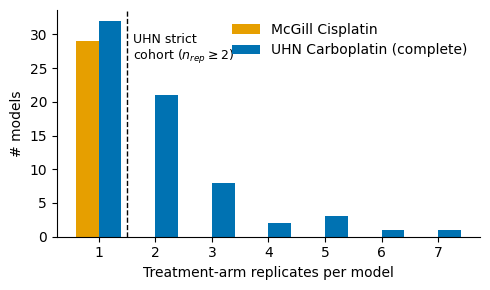

In [9]:
max_rep = int(max(mcgill_reps.max(), uhn_reps.max()))
bins = np.arange(1, max_rep + 1)

mcgill_counts = mcgill_reps.value_counts().reindex(bins, fill_value=0)
uhn_counts = uhn_reps.value_counts().reindex(bins, fill_value=0)

fig, ax = plt.subplots(figsize=(5, 3))
width = 0.4
ax.bar(bins - width / 2, mcgill_counts, width, label="McGill Cisplatin", color=COHORT_COLORS["McGill Cisplatin"])
ax.bar(bins + width / 2, uhn_counts, width, label="UHN Carboplatin (complete)", color=COHORT_COLORS["UHN Carboplatin"])

ax.axvline(1.5, color="black", linestyle="--", linewidth=1)
ax.text(1.5 + 0.1, ax.get_ylim()[1] * 0.9, "UHN strict\ncohort ($n_{rep} \\geq 2$)", fontsize=9, va="top")

ax.set_xticks(bins)
ax.set_xlabel("Treatment-arm replicates per model")
ax.set_ylabel("# models")
ax.legend(frameon=False, loc="upper right")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()

out_path = figures_dir / "case3_replicate_histogram.png"
plt.savefig(out_path, dpi=300)
print("Saved:", out_path)
plt.show()

#### Single- vs multi-replicate model counts, McGill vs UHN complete vs UHN strict

Saved: /Users/guanqiaofeng/Documents/BHK/XevaDB/Manuscript_gitrepo/XevaDB_case_study/results/3_carboplatin/case3_replicate_single_vs_multi.png


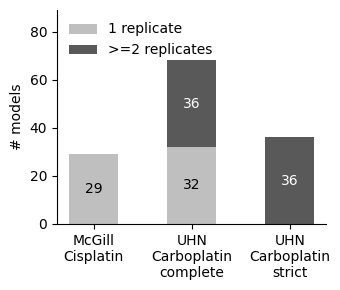

In [10]:
cohort_reps = {
    "McGill\nCisplatin": mcgill_reps,
    "UHN\nCarboplatin\ncomplete": uhn_reps,
    "UHN\nCarboplatin\nstrict": uhn_strict_reps,
}

single = [int((r == 1).sum()) for r in cohort_reps.values()]
multi = [int((r >= 2).sum()) for r in cohort_reps.values()]

x = np.arange(len(cohort_reps))
fig, ax = plt.subplots(figsize=(3.5, 3))
ax.bar(x, single, label="1 replicate", color="0.75", width=0.5)
ax.bar(x, multi, bottom=single, label=">=2 replicates", color="0.35", width=0.5)

for i, (s, m) in enumerate(zip(single, multi)):
    if s:
        ax.text(i, s / 2, str(s), ha="center", va="center", fontsize=10, color="black")
    if m:
        ax.text(i, s + m / 2, str(m), ha="center", va="center", fontsize=10, color="white")

ax.set_xticks(x)
ax.set_xticklabels(cohort_reps.keys())
ax.set_ylabel("# models")
ax.set_ylim(0,89)
ax.legend(frameon=False, loc="upper left")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()

out_path = figures_dir / "case3_replicate_single_vs_multi.png"
plt.savefig(out_path, dpi=300)
print("Saved:", out_path)
plt.show()

### PCA of NeST-VNN input features: Mutation / CNA / CND (McGill vs UHN)

Saved: /Users/guanqiaofeng/Documents/BHK/XevaDB/Manuscript_gitrepo/XevaDB_case_study/results/3_carboplatin/case3_pca_panel.png


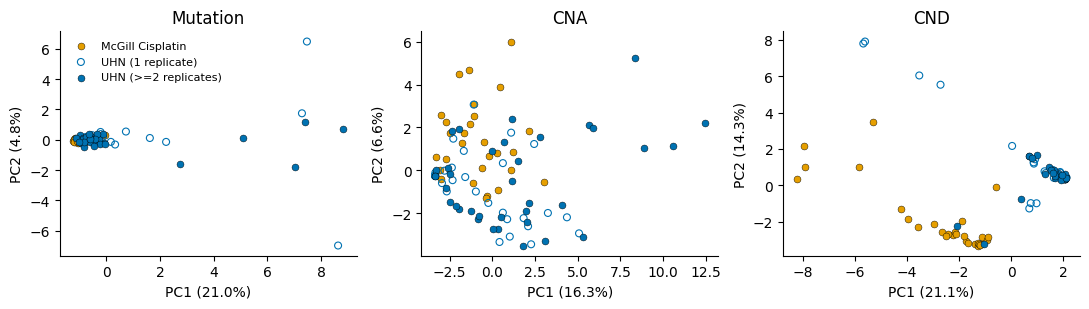

In [11]:
from sklearn.decomposition import PCA

FEATURE_FILES = {
    "Mutation": "cell2mutation.txt",
    "CNA": "cell2amplification.txt",
    "CND": "cell2cndeletion.txt",
}


def load_nest_matrix(nest_dir, fname):
    return pd.read_csv(nest_dir / fname, header=None).to_numpy()


is_strict = (uhn_models["n_replicates"] >= 2).to_numpy()

fig, axes = plt.subplots(1, 3, figsize=(11, 3.2))

for ax, ft in zip(axes, ["Mutation", "CNA", "CND"]):
    mcgill_mat = load_nest_matrix(mcgill_dir, FEATURE_FILES[ft])
    uhn_mat = load_nest_matrix(uhn_complete_dir, FEATURE_FILES[ft])

    combined = np.vstack([mcgill_mat, uhn_mat])
    pca = PCA(n_components=2)
    coords = pca.fit_transform(combined)

    mcgill_xy = coords[: len(mcgill_mat)]
    uhn_xy = coords[len(mcgill_mat) :]

    ax.scatter(mcgill_xy[:, 0], mcgill_xy[:, 1], color=COHORT_COLORS["McGill Cisplatin"],
               edgecolor="black", linewidth=0.3, s=25, label="McGill Cisplatin")
    ax.scatter(uhn_xy[~is_strict, 0], uhn_xy[~is_strict, 1], facecolors="none",
               edgecolors=COHORT_COLORS["UHN Carboplatin"], linewidth=0.8, s=25,
               label="UHN (1 replicate)")
    ax.scatter(uhn_xy[is_strict, 0], uhn_xy[is_strict, 1], color=COHORT_COLORS["UHN Carboplatin"],
               edgecolor="black", linewidth=0.3, s=25, label="UHN (>=2 replicates)")

    ax.set_title(ft)
    ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0] * 100:.1f}%)")
    ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1] * 100:.1f}%)")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

axes[0].legend(frameon=False, fontsize=8, loc="best")
plt.tight_layout()

out_path = figures_dir / "case3_pca_panel.png"
plt.savefig(out_path, dpi=300)
print("Saved:", out_path)
plt.show()

### Sensitivity validation statistic: growth-curve slope (arctan angle, degrees, bounded +/-90)

Saved: /Users/guanqiaofeng/Documents/BHK/XevaDB/Manuscript_gitrepo/XevaDB_case_study/results/3_carboplatin/case3_slope_distribution.png


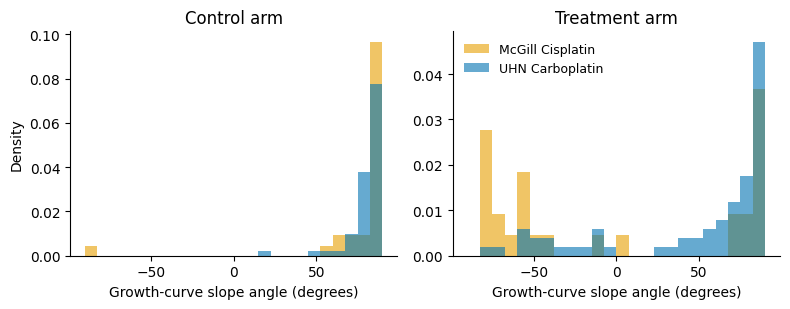

slope.control: KS D=0.357, p=8.21e-03
    McGill: n=29, mean=77.3, median=86.7, std=32.8, range=[-87.0, 89.4]
    UHN: n=67, mean=81.0, median=83.7, std=10.5, range=[22.2, 88.7]
slope.treatment: KS D=0.414, p=1.19e-03
    McGill: n=29, mean=-0.2, median=-44.8, std=74.1, range=[-82.0, 89.0]
    UHN: n=68, mean=48.1, median=74.1, std=51.3, range=[-75.0, 89.2]


In [12]:
from scipy.stats import ks_2samp

fig, axes = plt.subplots(1, 2, figsize=(8, 3.2))
bins = np.linspace(-90, 90, 25)

for ax, col, title in zip(axes, ["slope.control", "slope.treatment"], ["Control arm", "Treatment arm"]):
    ax.hist(mcgill_models[col].dropna(), bins=bins, density=True, alpha=0.6,
            color=COHORT_COLORS["McGill Cisplatin"], label="McGill Cisplatin")
    ax.hist(uhn_models[col].dropna(), bins=bins, density=True, alpha=0.6,
            color=COHORT_COLORS["UHN Carboplatin"], label="UHN Carboplatin")
    ax.set_title(title)
    ax.set_xlabel("Growth-curve slope angle (degrees)")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

axes[0].set_ylabel("Density")
axes[1].legend(frameon=False, fontsize=9)
plt.tight_layout()

out_path = figures_dir / "case3_slope_distribution.png"
plt.savefig(out_path, dpi=300)
print("Saved:", out_path)
plt.show()

for col in ["slope.control", "slope.treatment"]:
    stat, p = ks_2samp(mcgill_models[col].dropna(), uhn_models[col].dropna())
    print(f"{col}: KS D={stat:.3f}, p={p:.2e}")
    for name, df in [("McGill", mcgill_models), ("UHN", uhn_models)]:
        s = df[col].dropna()
        print(f"    {name}: n={len(s)}, mean={s.mean():.1f}, median={s.median():.1f}, "
              f"std={s.std():.1f}, range=[{s.min():.1f}, {s.max():.1f}]")

#### Treatment-arm-only panel (main figure), with the growth/regression threshold at 0deg marked

Saved: /Users/guanqiaofeng/Documents/BHK/XevaDB/Manuscript_gitrepo/XevaDB_case_study/results/3_carboplatin/case3_slope_treatment_only.png


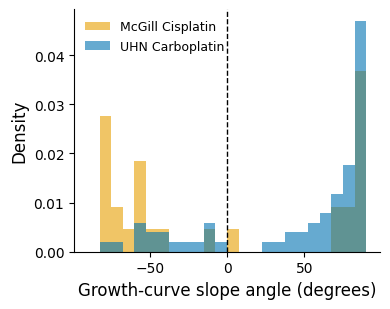

In [13]:
fig, ax = plt.subplots(figsize=(4, 3.2))
bins = np.linspace(-90, 90, 25)

ax.hist(mcgill_models["slope.treatment"].dropna(), bins=bins, density=True, alpha=0.6,
        color=COHORT_COLORS["McGill Cisplatin"], label="McGill Cisplatin")
ax.hist(uhn_models["slope.treatment"].dropna(), bins=bins, density=True, alpha=0.6,
        color=COHORT_COLORS["UHN Carboplatin"], label="UHN Carboplatin")

ax.axvline(0, color="black", linestyle="--", linewidth=1)

ax.set_xlabel("Growth-curve slope angle (degrees)", fontsize=12)
ax.set_ylabel("Density", fontsize = 12)
ax.legend(frameon=False, fontsize=9)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()

out_path = figures_dir / "case3_slope_treatment_only.png"
plt.savefig(out_path, dpi=300)
print("Saved:", out_path)
plt.show()